In [25]:
import pandas as pd

df = pd.read_csv("ecommerce_sales_analysis.csv")  # 형식에 따라 read_json, read_parquet 등 변경
df.shape  # (행, 열)
df.head()

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257


In [30]:
# 기본 확인
print(df.shape)               # 행/열 수
print(df.columns.tolist())    # 컬럼명 확인
df.head()                     # 데이터 미리보기

(1000, 18)
['product_id', 'product_name', 'category', 'price', 'review_score', 'review_count', 'sales_month_1', 'sales_month_2', 'sales_month_3', 'sales_month_4', 'sales_month_5', 'sales_month_6', 'sales_month_7', 'sales_month_8', 'sales_month_9', 'sales_month_10', 'sales_month_11', 'sales_month_12']


,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257


In [32]:
# 컬럼별 결측치 개수
print(df.isnull().sum())

# 결측치 비율 보기
print(df.isnull().mean().sort_values(ascending=False))

product_id        0
product_name      0
category          0
price             0
review_score      0
review_count      0
sales_month_1     0
sales_month_2     0
sales_month_3     0
sales_month_4     0
sales_month_5     0
sales_month_6     0
sales_month_7     0
sales_month_8     0
sales_month_9     0
sales_month_10    0
sales_month_11    0
sales_month_12    0
dtype: int64
product_id        0.0
product_name      0.0
sales_month_11    0.0
sales_month_10    0.0
sales_month_9     0.0
sales_month_8     0.0
sales_month_7     0.0
sales_month_6     0.0
sales_month_5     0.0
sales_month_4     0.0
sales_month_3     0.0
sales_month_2     0.0
sales_month_1     0.0
review_count      0.0
review_score      0.0
price             0.0
category          0.0
sales_month_12    0.0
dtype: float64


In [34]:
# 데이터 타입 확인
print(df.dtypes)

# sales 관련 컬럼 추출
sales_cols = [col for col in df.columns if 'sales_month' in col]

# sales 컬럼이 숫자인지 확인
print(df[sales_cols].dtypes)

product_id          int64
product_name       object
category           object
price             float64
review_score      float64
review_count        int64
sales_month_1       int64
sales_month_2       int64
sales_month_3       int64
sales_month_4       int64
sales_month_5       int64
sales_month_6       int64
sales_month_7       int64
sales_month_8       int64
sales_month_9       int64
sales_month_10      int64
sales_month_11      int64
sales_month_12      int64
dtype: object
sales_month_1     int64
sales_month_2     int64
sales_month_3     int64
sales_month_4     int64
sales_month_5     int64
sales_month_6     int64
sales_month_7     int64
sales_month_8     int64
sales_month_9     int64
sales_month_10    int64
sales_month_11    int64
sales_month_12    int64
dtype: object


In [17]:
key_cols = ['review_content', 'rating', 'category', 'discount_percentage', 'product_name']
print("중요 컬럼 존재 여부:")
for col in key_cols:
    print(f"- {col}: {'O' if col in df.columns else 'X'}")

중요 컬럼 존재 여부:
- review_content: O
- rating: O
- category: O
- discount_percentage: O
- product_name: O


In [19]:
top_products = df['product_name'].value_counts().head(10)
print("리뷰 수 기준 상위 10개 제품:\n", top_products)

리뷰 수 기준 상위 10개 제품:
 product_name
Fire-Boltt Ninja Call Pro Plus 1.83" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution             5
Fire-Boltt Phoenix Smart Watch with Bluetooth Calling 1.3",120+ Sports Modes, 240*240 PX High Res with SpO2, Heart Rate Monitoring & IP67 Rating                      4
Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)    3
MI Braided USB Type-C Cable for Charging Adapter (Red)                                                                                                                3
Amazonbasics Nylon Braided Usb-C To Lightning Cable, Fast Charging Mfi Certified Smartphone, Iphone Charger (6-Foot, Dark Grey)                                       3
Samsung Galaxy M13 5G (Aqua Green, 6GB, 128GB Storage) | 5000mAh Battery | Upto 12GB RAM with RAM Plus                         

In [21]:
# 완전 중복 확인
print("완전 중복:", df.duplicated().sum())

# 리뷰 ID 기준 중복
print("리뷰 ID 기준 중복:", df.duplicated(subset='review_id').sum())

# 리뷰 내용 + 제품 ID 기준 중복
print("리뷰내용+제품 기준 중복:", df.duplicated(subset=['review_content', 'product_id']).sum())

완전 중복: 0
리뷰 ID 기준 중복: 271
리뷰내용+제품 기준 중복: 95


C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48624 (\N{HANGUL SYLLABLE BYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

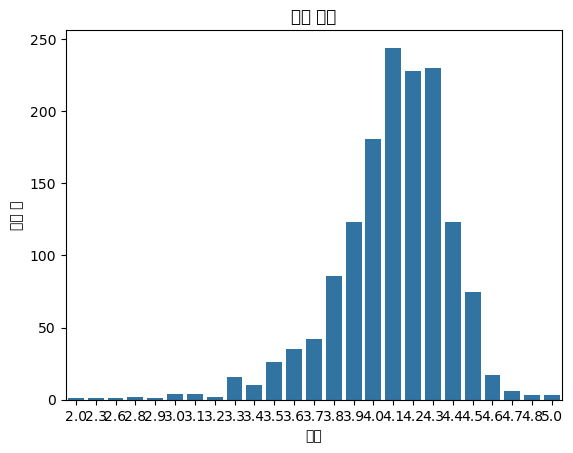

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='rating', data=df)
plt.title("별점 분포")
plt.xlabel("별점")
plt.ylabel("리뷰 수")
plt.show()